In [37]:
# import packages
from sodapy import Socrata
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
import contextily as cx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [3]:
# Unauthenticated client only works with public data sets. Note 'None'
# in place of application token, and no username or password:
client = Socrata("data.cityofnewyork.us", 
                 "wwEtFa2r5tCRHQJ3bCWgIdn4Y")

# Example authenticated client (needed for non-public datasets):
# client = Socrata(data.cityofnewyork.us,
#                  MyAppToken,
#                  username="user@example.com",
#                  password="AFakePassword")

# First 2000 results, returned as JSON from API / converted to Python list of
# dictionaries by sodapy.
results = client.get("mrjc-v9pm", limit=2000)

# Convert to pandas DataFrame
results_df = pd.DataFrame.from_records(results)

In [4]:
print(results_df)

                                               the_geom        geoid fshri  \
0     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36005008500     5   
1     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36081008600     5   
2     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047058000     5   
3     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047053200     5   
4     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36081004500     5   
...                                                 ...          ...   ...   
1995  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36005025700     1   
1996  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047048900     1   
1997  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36061012700     1   
1998  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047018300     1   
1999  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047013700     1   

     ss_80s ss_cur ss_50s tid_80s tid_20s tid_50s  
0       NaN

## Data Cleaning

In [5]:
df = results_df.copy()

# Replace NaNs with 0's
df.fillna(0, inplace = True)


In [6]:
# Change data types of certain numerical columns from object to ints
col_list = ["ss_80s", "ss_cur", "ss_50s",
            "tid_80s", "tid_20s", "tid_50s"]

conv_dict = {col : "int32" for col in col_list}

df = df.astype(conv_dict)

In [7]:
df.dtypes

the_geom    object
geoid       object
fshri       object
ss_80s       int32
ss_cur       int32
ss_50s       int32
tid_80s      int32
tid_20s      int32
tid_50s      int32
dtype: object

In [8]:
print(df)

                                               the_geom        geoid fshri  \
0     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36005008500     5   
1     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36081008600     5   
2     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047058000     5   
3     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047053200     5   
4     {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36081004500     5   
...                                                 ...          ...   ...   
1995  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36005025700     1   
1996  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047048900     1   
1997  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36061012700     1   
1998  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047018300     1   
1999  {'type': 'MultiPolygon', 'coordinates': [[[[-7...  36047013700     1   

      ss_80s  ss_cur  ss_50s  tid_80s  tid_20s  tid_50s  
0    

In [9]:
df.describe()

,ss_80s,ss_cur,ss_50s,tid_80s,tid_20s,tid_50s
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.829500,0.473000,0.688500,0.227500,0.102000,0.110000
std,1.561617,1.248219,1.456203,0.899527,0.604797,0.630158
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [10]:
for col in col_list:
    print(df[col].value_counts())

ss_80s
0    1465
5     123
4     113
2     103
1     101
3      95
Name: count, dtype: int64
ss_cur
0    1692
5      73
1      62
2      59
4      59
3      55
Name: count, dtype: int64
ss_50s
0    1555
5     104
4      89
1      85
2      85
3      82
Name: count, dtype: int64
tid_80s
0    1854
5      34
4      31
1      28
3      27
2      26
Name: count, dtype: int64
tid_20s
0    1932
2      16
5      15
1      13
3      12
4      12
Name: count, dtype: int64
tid_50s
0    1927
5      16
2      16
1      15
4      15
3      11
Name: count, dtype: int64


## EDA

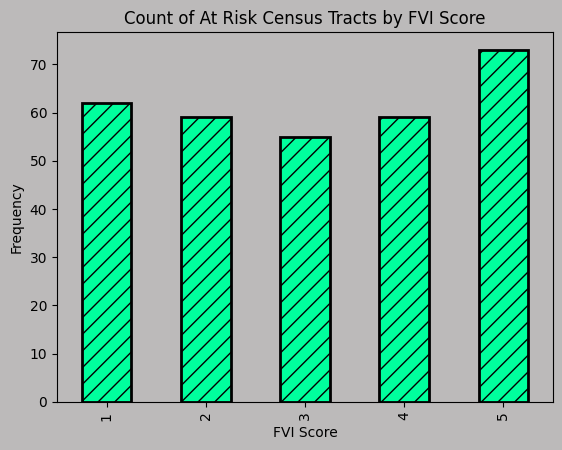

In [11]:
dfv = df.copy()
dfp = dfv[dfv['ss_cur'] != 0]

# The main plot
ax = dfp['ss_cur'].value_counts().sort_index().plot(
    kind='bar', 
    color="#00ff9d",
    edgecolor = 'black',
    linewidth = 2,
    hatch = '//',
    xlabel = 'FVI Score',
    ylabel = 'Frequency',
    title = 'Count of At Risk Census Tracts by FVI Score'
    )

# Modifying further aesthetics
ax.set_facecolor("#bcbabaff")
ax.figure.set_facecolor("#bcbabaff")

## Geopandas Practice

In [12]:
# Convert the_geom GeoJSON format to a shape
df['geometry'] = df['the_geom'].apply(shape)

# Initialize GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry = 'geometry')

# Set coordinate system
gdf.crs = "EPSG:4326"


In [13]:
# Clean FSHRI
gdf['fshri'].isna().sum()
gdf = gdf.astype({'fshri' : 'int32'})

In [14]:
gdf.dtypes

the_geom      object
geoid         object
fshri          int32
ss_80s         int32
ss_cur         int32
ss_50s         int32
tid_80s        int32
tid_20s        int32
tid_50s        int32
geometry    geometry
dtype: object

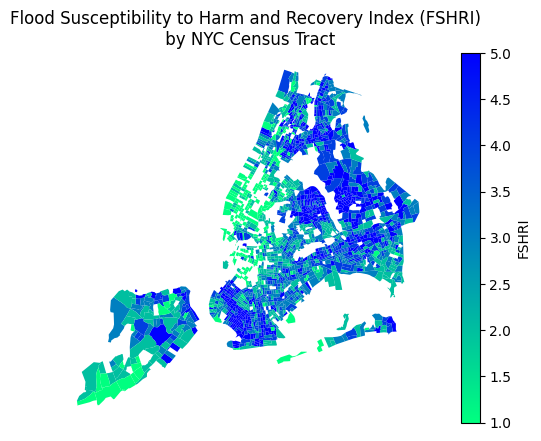

In [ ]:
ax = gdf.plot(
    column = 'fshri',
    cmap = 'winter_r',
    legend = True,
    legend_kwds = {"label": "FSHRI"}
)

ax.set_title('Flood Susceptibility to Harm and Recovery Index (FSHRI) \n by NYC Census Tract')
ax.set_axis_off()

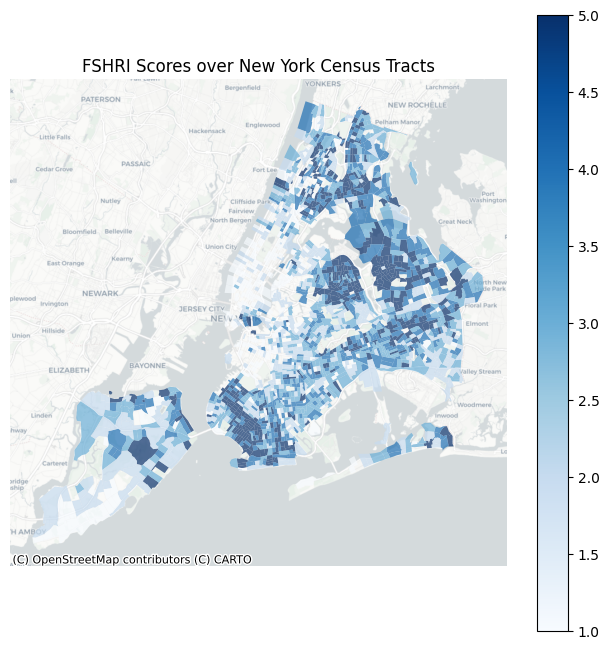

In [16]:
# Convert your data to Web Mercator so it matches the background tiles
gdf_web = gdf.to_crs(epsg=3857)

# Plot
ax = gdf_web.plot(
      column='fshri', 
      cmap='Blues',
      alpha=0.7, 
      legend=True,
      figsize=(8, 8)
      )

# Add base map
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title('FSHRI Scores over New York Census Tracts')
ax.set_axis_off()
plt.show()

## Map Storm Surge projection variables
*ss_cur, ss_50s, ss_80s*

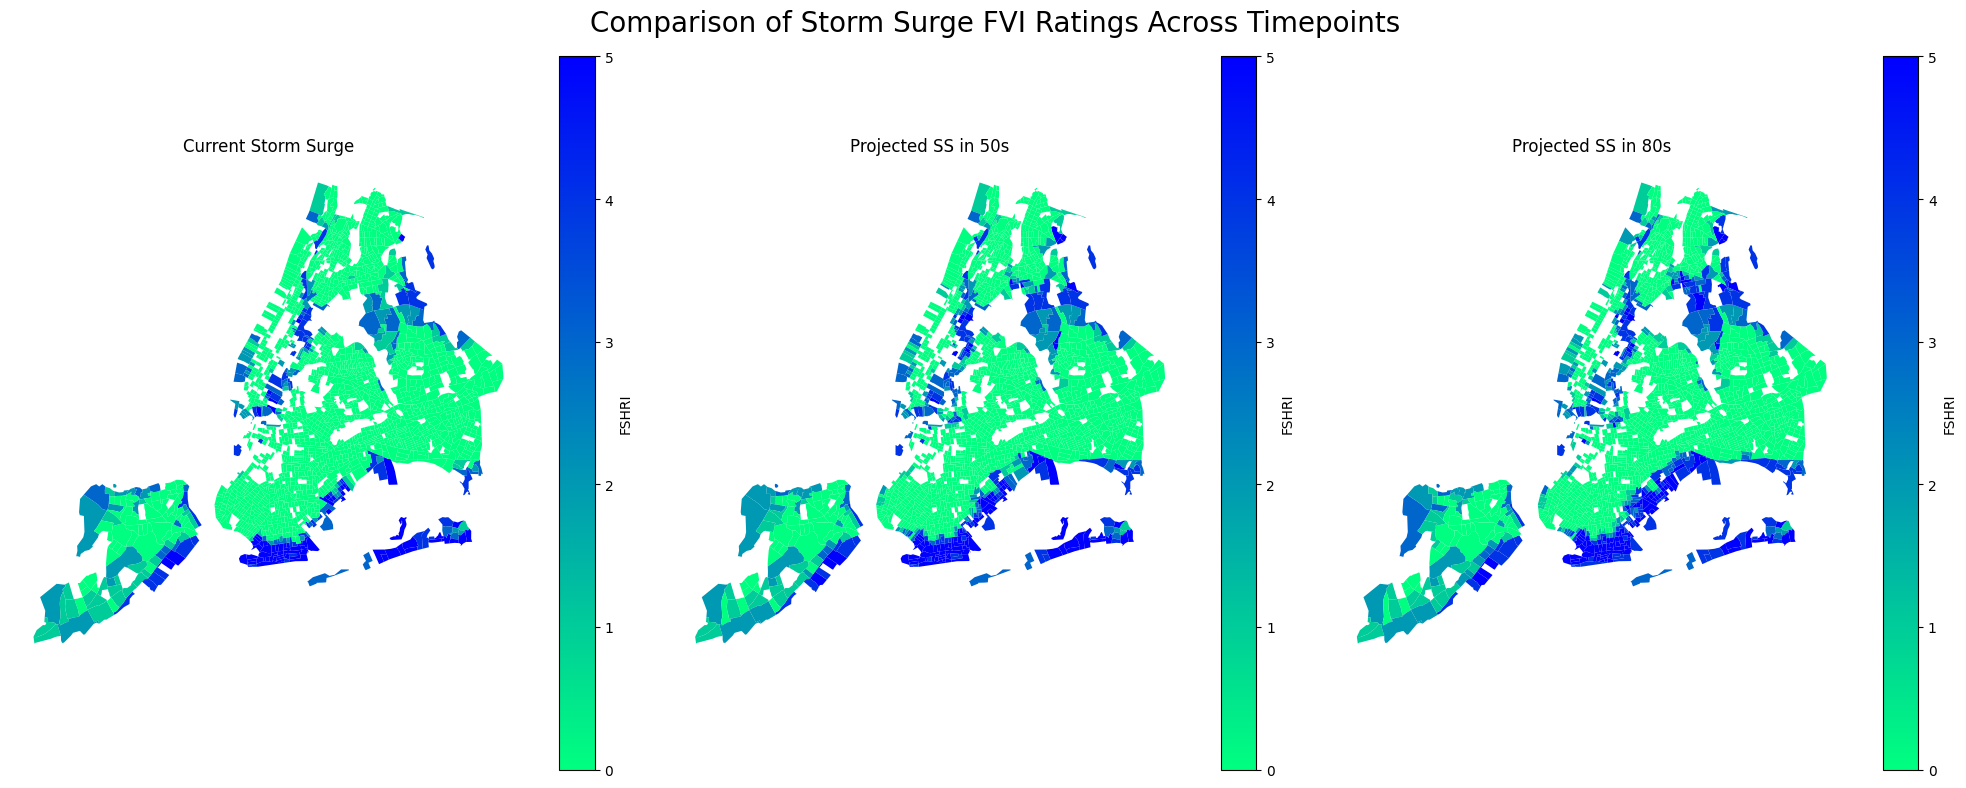

In [ ]:
# Plot three maps at once
# plt.subplots returns two different elements of a tuple, one we assign to fig and 
# the other we assign to the axes. fig controls the chart frame and ax objects
# tuple contains the plot objects we'll modify for this frame.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))

# ss_cur
# ax = ax1 points this plot to the ax1 position of above
gdf.plot(
    ax = ax1,
    column = 'ss_cur',
    cmap = 'winter_r',
    legend = True,
    legend_kwds = {"label": "FSHRI"}
)
ax1.set_title('Current Storm Surge')
ax1.set_axis_off()

# ss_50s
gdf.plot(
    ax = ax2,
    column = 'ss_50s',
    cmap = 'winter_r',
    legend = True,
    legend_kwds = {"label": "FSHRI"}
)
ax2.set_title('Projected SS in 50s')
ax2.set_axis_off()

# ss_80s
gdf.plot(
    ax = ax3,
    column = 'ss_80s',
    cmap = 'winter_r',
    legend = True,
    legend_kwds = {"label": "FSHRI"}
)
ax3.set_title('Projected SS in 80s')
ax3.set_axis_off()

# Add a main title for the whole figure
plt.suptitle('Comparison of Storm Surge FVI Ratings Across Timepoints', fontsize=20)
plt.tight_layout()
plt.show()

## Animate the Maps!

In [32]:
# Create a list of the columns you want to animate
timepoints = ['ss_cur', 'ss_50s', 'ss_80s']
titles = ['Current Storm Surge', 'Projected SS in 2050s', 'Projected SS in 2080s']

In [43]:
# 1. Initialize the Figure
fig, ax = plt.subplots(figsize=(10, 8))
vmin, vmax = gdf[timepoints].min().min(), gdf[timepoints].max().max()

# 2. Create a permanent colorbar OUTSIDE the update function
# We use a ScalarMappable so the legend stays still while the map changes
sm = plt.cm.ScalarMappable(cmap='winter_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, ax=ax, label="FSHRI", shrink=0.6)

def update(frame):
    ax.clear()  # This is the safest way to reset the plot area
    col = timepoints[frame]
    
    # Draw the map (Note: legend=False so we don't get duplicates)
    gdf.plot(
        ax=ax, 
        column=col, 
        cmap='winter_r', 
        vmin=vmin, 
        vmax=vmax
    )
    
    # Since ax.clear() wipes these, we re-set them every frame
    ax.set_title(titles[frame], fontsize=16)
    ax.set_axis_off()

# 3. Create and render the animation
ani = FuncAnimation(fig, update, frames=len(timepoints), interval=2000, repeat=True)

plt.close() # Prevents the extra static image
HTML(ani.to_jshtml())